<a href="https://colab.research.google.com/github/EduardoKenzoHayashi/CN-Lobosco/blob/main/Atividade1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

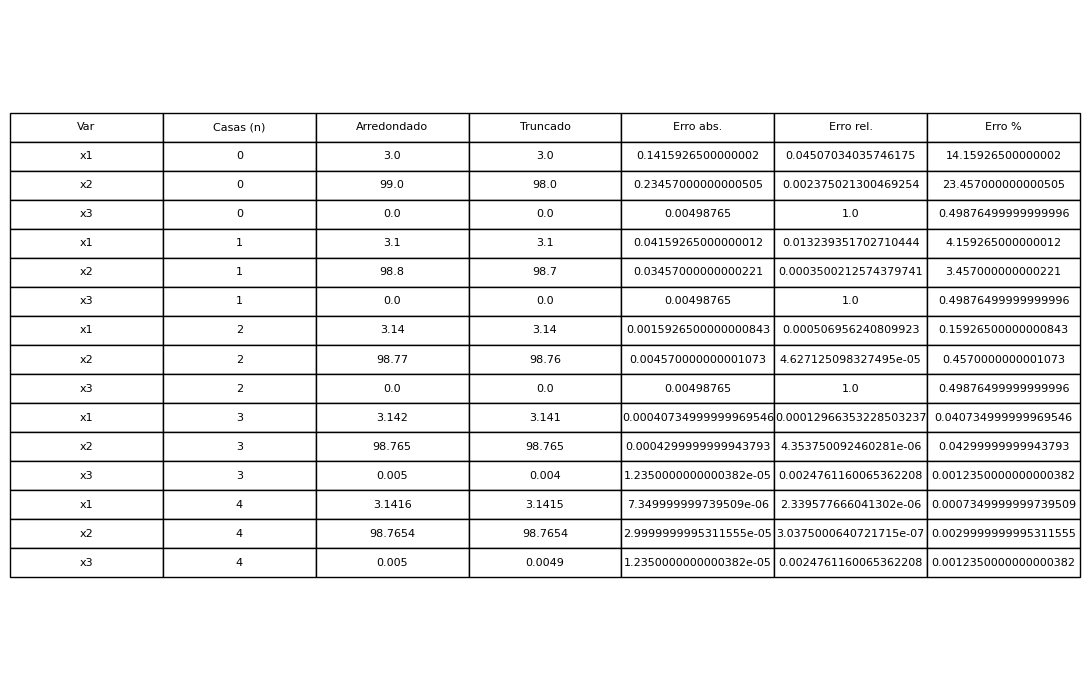

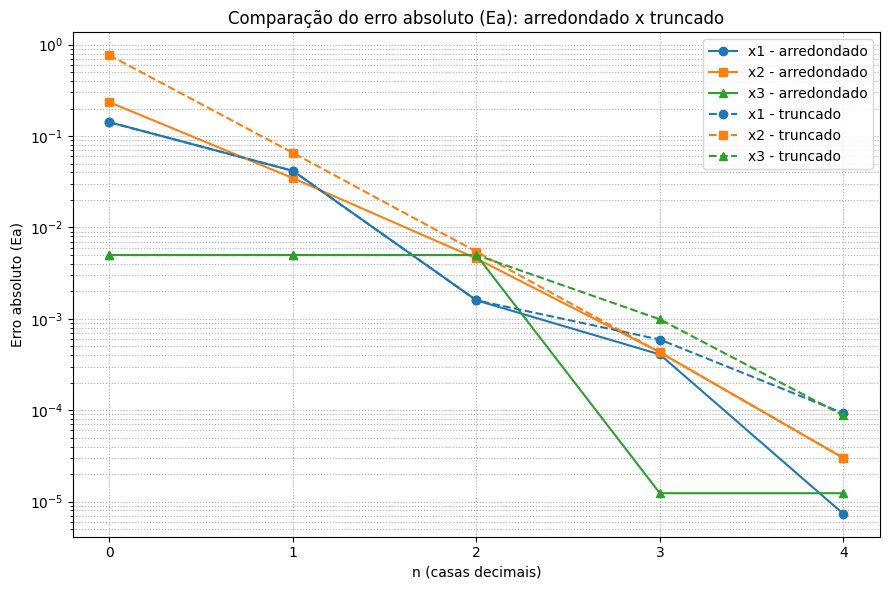

In [31]:
import math
import numpy as np
import matplotlib.pyplot as plt
def truncar(numero, casas):
    # Calcula o fator que desloca a vírgula decimal.
    fator = 10 ** casas

    # Trunca o número deslocado e devolve a vírgula à posição original.
    return math.trunc(numero * fator) / fator

def err_abs(x,n):
  return abs(x-round(x,n))

def err_rel(err,x):
  return err/abs(x)

def err_per(err):
  return err*100

x1 = 3.14159265
x2 = 98.76543
x3 = 0.00498765
linhas = []
for n in range(0,5):
  linhas.append(["x1", n, round(x1,n), truncar(x1,n), err_abs(x1,n), err_rel(err_abs(x1,n), x1), err_per(err_abs(x1,n))])
  linhas.append(["x2", n, round(x2,n), truncar(x2,n), err_abs(x2,n), err_rel(err_abs(x2,n), x2), err_per(err_abs(x2,n))])
  linhas.append(["x3", n, round(x3,n), truncar(x3,n), err_abs(x3,n), err_rel(err_abs(x3,n), x3), err_per(err_abs(x3,n))])
#fim for
colunas = [
    "Var", "Casas (n)", "Arredondado",
    "Truncado", "Erro abs.", "Erro rel.", "Erro %"
]

fig, ax = plt.subplots(figsize=(11, 7))
ax.axis('off')

tabela = ax.table(cellText=linhas, colLabels=colunas, loc='center', cellLoc='center')
tabela.auto_set_font_size(False)
tabela.set_fontsize(8)
tabela.scale(1, 1.4)
plt.tight_layout()
plt.show()
# --- Gráfico de Ea em função de n (escala log no eixo y) ---

# Função auxiliar para calcular o erro absoluto do valor TRUNCADO.
# Repara que é igual à ideia do err_abs, mas comparando x com truncar(x, n)
# em vez de comparar x com round(x, n).
def err_abs_trunc(x, n):
    return abs(x - truncar(x, n))

# Lista com os valores de n usados na tabela (0, 1, 2, 3, 4).
ns = list(range(0, 5))

# --- Erros absolutos usando ARREDONDAMENTO (round) ---
# Para cada n, calcula o Ea de x1 comparando x1 com round(x1, n).
ea_x1_round = [err_abs(x1, n) for n in ns]
# Mesma lógica para x2.
ea_x2_round = [err_abs(x2, n) for n in ns]
# Mesma lógica para x3.
ea_x3_round = [err_abs(x3, n) for n in ns]

# --- Erros absolutos usando TRUNCAMENTO (truncar) ---
# Para cada n, calcula o Ea de x1 comparando x1 com truncar(x1, n).
ea_x1_trunc = [err_abs_trunc(x1, n) for n in ns]
# Mesma lógica para x2.
ea_x2_trunc = [err_abs_trunc(x2, n) for n in ns]
# Mesma lógica para x3.
ea_x3_trunc = [err_abs_trunc(x3, n) for n in ns]

# Cria uma nova figura (janela do gráfico) com tamanho 9x6 polegadas.
plt.figure(figsize=(9, 6))

# --- Curvas do arredondamento (linha cheia) ---
# Plota Ea de x1 (arredondado) em função de n, com escala log no eixo Y.
#sesmiology é usado quando os dados têm uma diferença muito grande de escala entre os valores, e um gráfico linear normal esconderia essa diferença.
plt.semilogy(ns, ea_x1_round, marker='o', linestyle='-', color='tab:blue', label='x1 - arredondado')
# Plota Ea de x2 (arredondado) em função de n.
plt.semilogy(ns, ea_x2_round, marker='s', linestyle='-', color='tab:orange', label='x2 - arredondado')
# Plota Ea de x3 (arredondado) em função de n.
plt.semilogy(ns, ea_x3_round, marker='^', linestyle='-', color='tab:green', label='x3 - arredondado')

# --- Curvas do truncamento (linha tracejada, mesma cor da variável correspondente) ---
# Plota Ea de x1 (truncado) em função de n. Usa a mesma cor de x1 arredondado,
# mas com linha tracejada ('--'), para ficar fácil comparar visualmente o par.
plt.semilogy(ns, ea_x1_trunc, marker='o', linestyle='--', color='tab:blue', label='x1 - truncado')
# Plota Ea de x2 (truncado) em função de n.
plt.semilogy(ns, ea_x2_trunc, marker='s', linestyle='--', color='tab:orange', label='x2 - truncado')
# Plota Ea de x3 (truncado) em função de n.
plt.semilogy(ns, ea_x3_trunc, marker='^', linestyle='--', color='tab:green', label='x3 - truncado')

# Define o rótulo do eixo X.
plt.xlabel("n (casas decimais)")

# Define o rótulo do eixo Y.
plt.ylabel("Erro absoluto (Ea)")

# Define o título do gráfico, deixando claro que é uma comparação.
plt.title("Comparação do erro absoluto (Ea): arredondado x truncado")

# Garante que o eixo X mostre exatamente os valores inteiros de n (0,1,2,3,4).
plt.xticks(ns)

# Mostra a legenda com todas as 6 curvas (3 arredondadas + 3 truncadas).
plt.legend()

# Adiciona grade pontilhada nas linhas principais e secundárias
# (facilita muito a leitura em escala logarítmica).
plt.grid(True, which="both", ls=":")

# Ajusta os espaçamentos automaticamente para nada ficar cortado.
plt.tight_layout()

# Renderiza o gráfico na tela.
plt.show()

Olhando os gráficos, arredondar gera um erro menor ou igual ao erro absoluto gerado por valores truncados


In [32]:
orig = [121.7 , 120.4 , 122.1 , 119.8 , 121.2 , 120.9 , 122.4 , 121.0 , 120.2 , 121.5]
arre = []
trunc = []
def media(lista, qtd):
  soma = 0
  for i in lista:
    soma += i
  return soma / qtd

def minimo(lista):
  min = lista[0]
  for i in lista:
    if(i < min):
      min = i
  return min

def maximo(lista):
  max = lista[0]
  for i in lista:
    if(i > max):
      max = i
  return max

def amp(lista):
  mini = minimo(lista)
  maxi = maximo(lista)
  return abs(maxi - mini)

def desviop(lista, n):
  med = media(lista, n)
  desvio = 0
  for i  in lista:
    desvio += ((med - i) ** 2)
  desvio = (desvio / (n - 1)) ** (1/2)
  return desvio

for o in orig:
  arr = round(o , 0)
  arre.append(arr)
  trun = truncar(o , 0)
  trunc.append(trun)

medo = media(orig , 10)
mino = minimo(orig)
maxo = maximo(orig)
ampo = amp(orig)
dpo = desviop(orig , 10)

print(f"A média original é {medo}")
print(f"O mínimo original é {mino}")
print(f"O máximo original é {maxo}")
print(f"A amplitude original é {ampo}")
print(f"O desvio padrão original é {dpo}")

medarre = media(arre , 10)
mina = minimo(arre)
maxa = maximo(arre)
ampa = amp(arre)
dpa = desviop(arre , 10)

print(f"A média arredondada é {medarre}")
print(f"O mínimo arredondado é {mina}")
print(f"O máximo arredondado é {maxa}")
print(f"A amplitude arredondada é {ampa}")
print(f"O desvio padrão arredondado é {dpa}")

medtrunc = media(trunc , 10)
mint = minimo(trunc)
maxt = maximo(trunc)
ampt = amp(trunc)
dtp = desviop(trunc , 10)

print(f"A média truncada é {medtrunc}")
print(f"O minimo truncado é {mint}")
print(f"O máximo truncado é {maxt}")
print(f"A amplitude truncada é {ampt}")
print(f"O desvio padrão truncado é {dtp}")





A média original é 121.12
O mínimo original é 119.8
O máximo original é 122.4
A amplitude original é 2.6000000000000085
O desvio padrão original é 0.8337332373793856
A média arredondada é 121.1
O mínimo arredondado é 120.0
O máximo arredondado é 122.0
A amplitude arredondada é 2.0
O desvio padrão arredondado é 0.8755950357709131
A média truncada é 120.7
O minimo truncado é 119.0
O máximo truncado é 122.0
A amplitude truncada é 3.0
O desvio padrão truncado é 0.9486832980505138


In [33]:
def cebs(referencia, aproximado):
  return abs(referencia - aproximado)
eaarr = cebs (medo,medarre)
erarr = err_rel (eaarr, medo)
eparr = err_per (erarr)
print(f"O erro absoluto da média arredondada é {eaarr}")
print(f"O erro relativo da média arredondada é {erarr}")
print(f"O erro percentual da média arredondada é {eparr}")

eatrunc = cebs (medo, medtrunc)
ertrunc = err_rel (eatrunc, medo)
eptrunc = err_per (ertrunc)
print(f"O erro absoluto da média truncada é {eatrunc}")
print(f"O erro relativo da média truncada é {ertrunc}")
print(f"O erro percentual da média truncada é {eptrunc}")

O erro absoluto da média arredondada é 0.020000000000010232
O erro relativo da média arredondada é 0.0001651254953765706
O erro percentual da média arredondada é 0.01651254953765706
O erro absoluto da média truncada é 0.4200000000000017
O erro relativo da média truncada é 0.003467635402906223
O erro percentual da média truncada é 0.3467635402906223


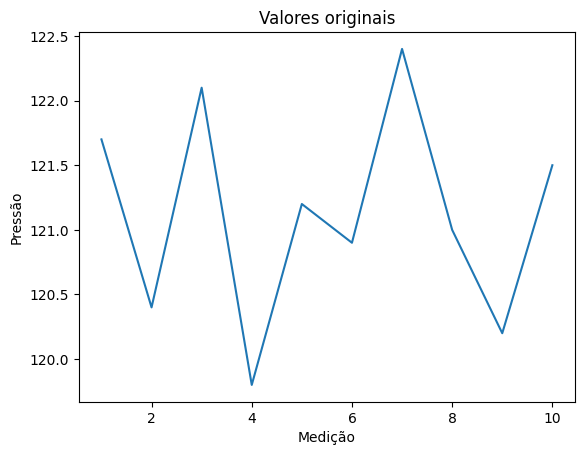

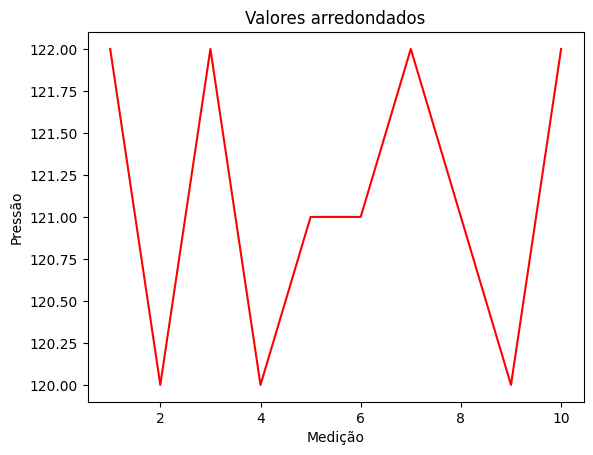

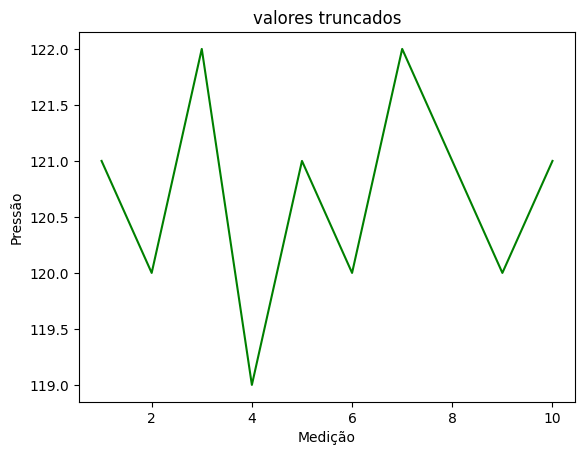

In [34]:
#há 10 valores, logo x varia de 1 até 10
x = np.arange(1, 11, 1)
#gráfico das medições original
plt.plot(x , orig)
plt.xlabel ("Medição")
plt.ylabel ("Pressão")
plt.title("Valores originais")
plt.show()

#gráfico das medições arredondadas
plt.plot(x, arre, color = "red")
plt.xlabel ("Medição")
plt.ylabel ("Pressão")
plt.title("Valores arredondados")
plt.show()

#gráfico dos valores truncados
plt.plot(x, trunc, color = "green")
plt.xlabel("Medição")
plt.ylabel ("Pressão")
plt.title("valores truncados")
plt.show()

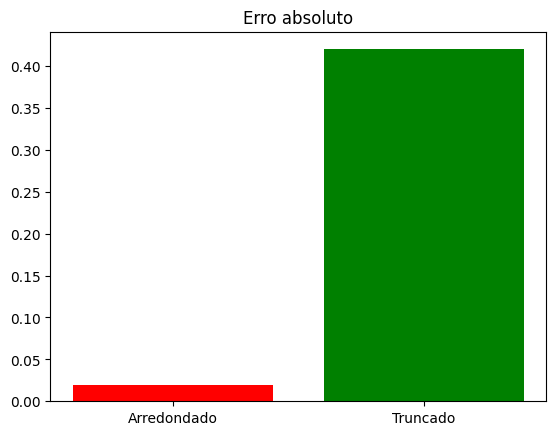

In [35]:

categorias = [ "Arredondado","Truncado" ]
erros_abs = [eaarr, eatrunc]
plt.bar(categorias,erros_abs,color = ["red","green"])
plt.title("Erro absoluto")
plt.show()

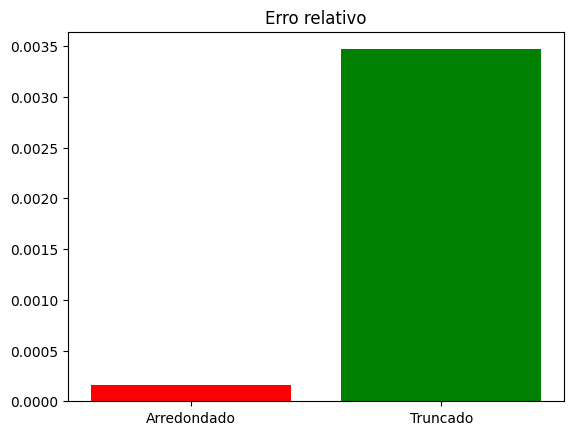

In [36]:
erros_rel = [erarr, ertrunc]
plt.bar(categorias, erros_rel, color = ['red','green'])
plt.title("Erro relativo")
plt.show()

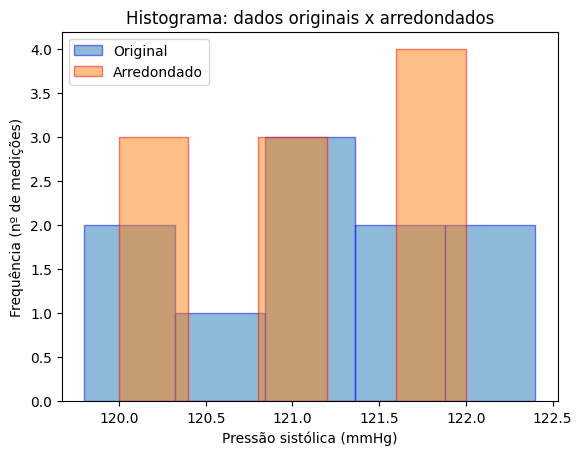

In [37]:
plt.hist(orig, bins = 5, alpha = 0.5, label = "Original", edgecolor = "blue")
plt.hist(arre, bins = 5 , alpha = 0.5, label = "Arredondado", edgecolor = 'red')
plt.xlabel('Pressão sistólica (mmHg)')
plt.ylabel('Frequência (nº de medições)')
plt.title('Histograma: dados originais x arredondados')
plt.legend()
plt.show()

Não, pois há dados nas casas decimais que seriam desprezadas pelo arredondamento ou truncamento que podem influenciar de forma significativa no cálculo da média e no cálculo do desvio padrão. Isso pode ser visto nos resultados obtidos ao compararmos o valor das médias e dos desvios padrões das três séries analisadas.

In [38]:
#função que calcula Q
def calQ(rmm, p, mi, L):
  return math.pi*((rmm*(10**-3))**4)*p/(8*mi*L)
ro = 0.8
Lo = 0.2
mio = 3.5e-3
pio = 1200

In [39]:
print(f"O valor de Q vale {calQ(ro,pio,mio,Lo)}")

O valor de Q vale 2.757420751950813e-07


In [40]:
ra = round(ro , 1)
rt = truncar(ro, 1)
Qo = calQ(ro,pio,mio,Lo)
Qra = calQ(ra,pio,mio,Lo)
Qrt = calQ(rt,pio,mio,Lo)

print(f"O valor de Q com r arredondado vale {Qra}")

eara = cebs(Qo,Qra)
erra = err_rel(eara, Qo)
epra = err_per(erra)

print(f"O erro absoluto de Q com r arredondado vale {eara}")
print(f"O erro relativo de Q com r arredondado vale {erra}")
print(f"O erro percentual de Q com r arredondado vale {epra}")

print(f"O valor de Q com r truncado vale {Qrt}")

eart = cebs(Qo,Qrt)
errt = err_rel(eart, Qo)
eprt = err_per(errt)

print(f"O erro absoluto de Q com r truncado vale {eart}")
print(f"O erro relativo de Q com r truncado vale {errt}")
print(f"O erro percentual de Q com r truncado vale {eprt}")



O valor de Q com r arredondado vale 2.757420751950813e-07
O erro absoluto de Q com r arredondado vale 0.0
O erro relativo de Q com r arredondado vale 0.0
O erro percentual de Q com r arredondado vale 0.0
O valor de Q com r truncado vale 2.757420751950813e-07
O erro absoluto de Q com r truncado vale 0.0
O erro relativo de Q com r truncado vale 0.0
O erro percentual de Q com r truncado vale 0.0


In [41]:
miar = round(mio, 3)
mit = truncar(mio, 3)
Qmiar = calQ(ro,pio,miar,Lo)
Qmit = calQ(ro,pio,mit,Lo)

print(f"O valor de Q com mi arredondado vale {Qmiar}")
eamiar = cebs(Qo,Qmiar)
ermiar = err_rel(eamiar, Qo)
epmiar = err_per(ermiar)
print(f"O erro absoluto de Q com mi arredondado vale {eamiar}")
print(f"O erro relativo de Q com mi arredondado vale {ermiar}")
print(f"O erro percentual de Q com mi arredondado vale {epmiar}")

print(f"O valor de Q com mi truncado vale {Qmit}")
eamit = cebs(Qo,Qmit)
ermit = err_rel(eamit, Qo)
epmit = err_per(ermit)
print(f'O erro absoluto de Q com mi truncado vale {eamit}')
print(f"O erro relativo de Q com mi truncado vale {ermit}")
print(f"O erro percentual de Q com mi truncado vale {epmit}")


O valor de Q com mi arredondado vale 2.4127431579569616e-07
O erro absoluto de Q com mi arredondado vale 3.446775939938513e-08
O erro relativo de Q com mi arredondado vale 0.12499999999999988
O erro percentual de Q com mi arredondado vale 12.499999999999988
O valor de Q com mi truncado vale 3.2169908772759484e-07
O erro absoluto de Q com mi truncado vale 4.5957012532513556e-08
O erro relativo de Q com mi truncado vale 0.16666666666666669
O erro percentual de Q com mi truncado vale 16.666666666666668


In [42]:
pat = 12
Qpat = calQ(ro,pat,mio,Lo)
print(f"O valor de Q com delta p arredondado/truncado vale {Qpat}")
eapat = cebs(Qo,Qpat)
erpat = err_rel(eapat, Qo)
eppat = err_per(erpat)
print(f"O erro absoluto de Q com delta p arredondado/truncado vale {eapat}")
print(f"O erro relativo de Q com delta p arredondado/truncado vale {erpat}")
print(f"O erro percentual de Q com delta p arredondado/truncado vale {eppat}")


O valor de Q com delta p arredondado/truncado vale 2.7574207519508133e-09
O erro absoluto de Q com delta p arredondado/truncado vale 2.7298465444313047e-07
O erro relativo de Q com delta p arredondado/truncado vale 0.99
O erro percentual de Q com delta p arredondado/truncado vale 99.0


In [43]:
Qtudoar = calQ(ra,pat,miar,Lo)
print(f"O valor de Q com tudo arredondado vale {Qtudoar}")
eatudo = cebs(Qo,Qtudoar)
ertudo = err_rel(eatudo, Qo)
eptudo = err_per(ertudo)
print(f"O erro absoluto de Q com tudo arredondado vale {eatudo}")
print(f"O erro relativo de Q com tudo arredondado vale {ertudo}")
print(f"O erro percentual de Q com tudo arredondado vale {eptudo}")

Qtudot = calQ(rt,pat,mit,Lo)
print(f"O valor de Q com tudo truncado vale {Qtudot}")
eatudo = cebs(Qo,Qtudot)
ertudo = err_rel(eatudo, Qo)
eptudo = err_per(ertudo)
print(f"O erro absoluto de Q com tudo truncado vale {eatudo}")
print(f"O erro relativo de Q com tudo truncado vale {ertudo}")
print(f"O erro percentual de Q com tudo truncado vale {eptudo}")

O valor de Q com tudo arredondado vale 2.4127431579569616e-09
O erro absoluto de Q com tudo arredondado vale 2.7332933203712433e-07
O erro relativo de Q com tudo arredondado vale 0.99125
O erro percentual de Q com tudo arredondado vale 99.125
O valor de Q com tudo truncado vale 3.216990877275949e-09
O erro absoluto de Q com tudo truncado vale 2.7252508431780536e-07
O erro relativo de Q com tudo truncado vale 0.9883333333333334
O erro percentual de Q com tudo truncado vale 98.83333333333334


In [44]:
rmm = np.arange(0.7,0.9+1e-9,0.01)
Qvaloresnorm = []
Qvaloresa = []
Qvalorest = []
for r in rmm:
  Qvaloresnorm.append(calQ(r,pio,mio,Lo))
  Qvaloresa.append(calQ(round(r,1),pio,mio,Lo))
  Qvalorest.append(calQ(truncar(r,1),pio,mio,Lo))


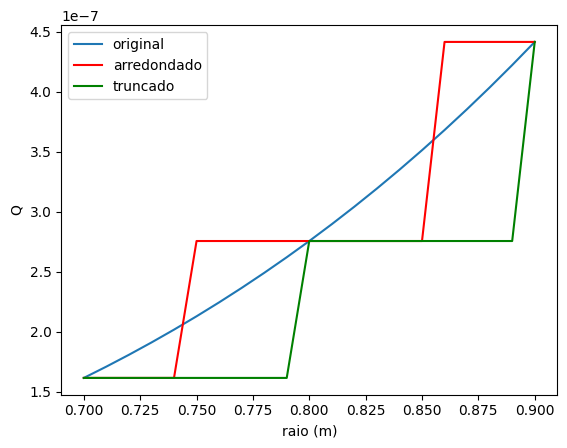

In [45]:
plt.plot(rmm, Qvaloresnorm, label = "original")
plt.plot(rmm, Qvaloresa, color = "red", label = "arredondado")
plt.plot(rmm, Qvalorest, color = "green", label = "truncado")
plt.xlabel("raio (m)")
plt.ylabel("Q")
plt.legend()
plt.show()

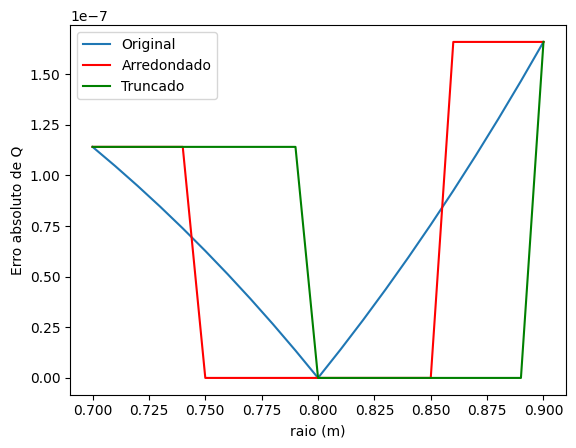

In [46]:
EaQn = []
for i in Qvaloresnorm:
  EaQn.append(cebs(Qo,i))

EaQa = []
for i in Qvaloresa:
  EaQa.append(cebs(Qo,i))

EaQt = []
for i in Qvalorest:
  EaQt.append(cebs(Qo,i))

plt.plot(rmm, EaQn, label = "Original")
plt.plot(rmm, EaQa, color = "red", label = "Arredondado")
plt.plot(rmm, EaQt, color = "green", label = "Truncado")
plt.xlabel("raio (m)")
plt.ylabel("Erro absoluto de Q")
plt.legend()
plt.show()

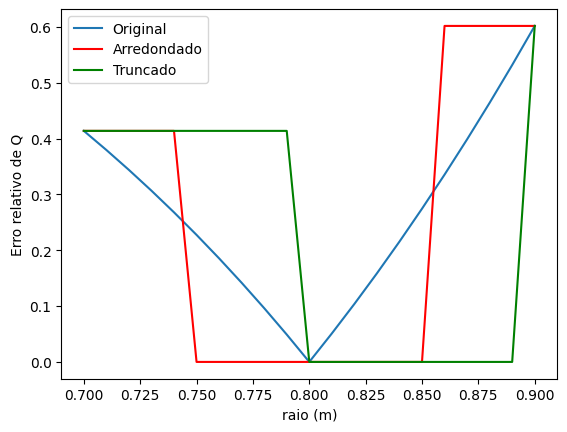

In [47]:
ErQn = []
ErQa = []
ErQt = []
for i in Qvaloresnorm:
  ErQn.append(err_rel(cebs(Qo,i),Qo))

for i in Qvaloresa:
  ErQa.append(err_rel(cebs(Qo,i),Qo))

for i in Qvalorest:
  ErQt.append(err_rel(cebs(Qo,i),Qo))


plt.plot(rmm, ErQn, label = "Original")
plt.plot(rmm, ErQa, color = "red", label = "Arredondado")
plt.plot(rmm, ErQt, color = "green", label = "Truncado")
plt.xlabel("raio (m)")
plt.ylabel("Erro relativo de Q")
plt.legend()
plt.show()

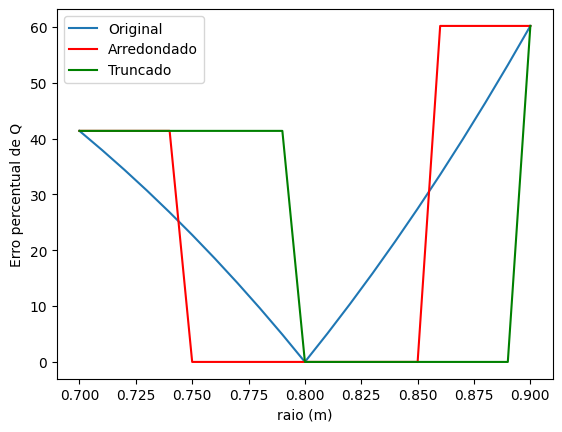

In [48]:
EpQn = []
EpQa = []
EpQt = []
for i in ErQn:
  EpQn.append(err_per(i))

for i in ErQa:
  EpQa.append(err_per(i))

for i in ErQt:
  EpQt.append(err_per(i))

plt.plot(rmm, EpQn, label = "Original")
plt.plot(rmm, EpQa, color = "red", label = "Arredondado")
plt.plot(rmm, EpQt, color = "green", label = "Truncado")
plt.xlabel("raio (m)")
plt.ylabel("Erro percentual de Q")
plt.legend()
plt.show()

O erro no raio é amplificado na vazão, pois na vazão, temos r^4, fazendo com que ele fique mais significativo

In [49]:
def calQd(rd, pd, mi, L):
  return math.pi*((rd)**4)*pd/(8*mi*L)

rd = 50e-9
Ld = 10e-6
mid = 3.5e-3
pd = 5000

Qd = calQd(rd,pd,mid,Ld)
print(f"O valor de Qd vale {Qd}")

O valor de Qd vale 3.506241800881465e-19


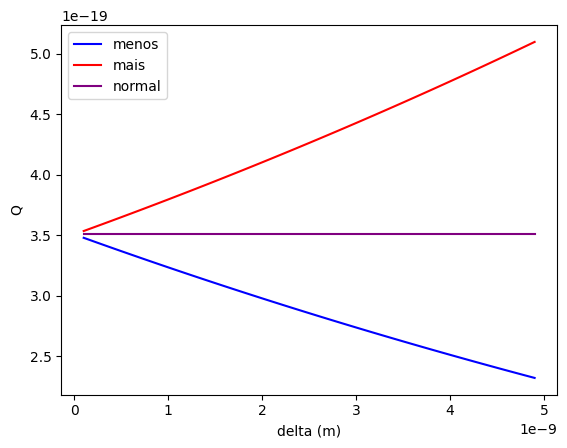

In [50]:
deltar = np.arange(0.1e-9,5e-9,0.1e-9)
def rmenos(r, deltar):
  #rmenos é o valor mínimo possível
  return r - deltar

def rmais(r, deltar):
  #rmais é o valor máximo possível
  return r + deltar
Qmenos = []
Qmais = []
Qnormal = []

for delta in deltar:
  Qmenos.append(calQd(rmenos(rd,delta),pd,mid,Ld))
  Qmais.append(calQd(rmais(rd,delta),pd,mid,Ld))
  Qnormal.append(calQd(rd,pd,mid,Ld))

plt.plot(deltar, Qmenos, label = "menos", color = "blue")
plt.plot(deltar, Qmais, label = "mais", color = "red")
plt.plot(deltar, Qnormal, label = "normal", color = "purple")
plt.xlabel("delta (m)")
plt.ylabel("Q")
plt.legend()
plt.show()

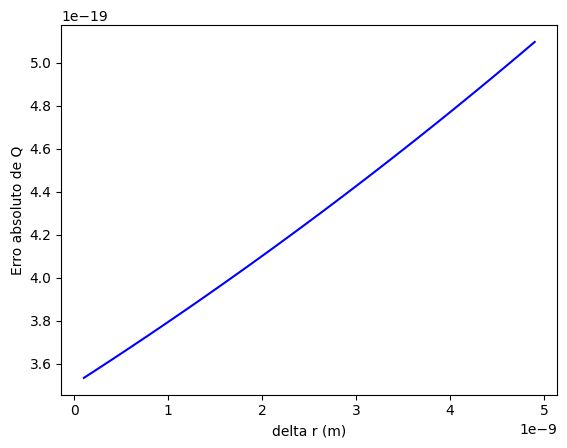

In [51]:
ead = []
for delta in deltar:
  ead.append(calQd(rmais(rd, delta),pd, mid, Ld ))
plt.plot(deltar, ead, color = "blue")
plt.xlabel("delta r (m)")
plt.ylabel("Erro absoluto de Q")
plt.show()

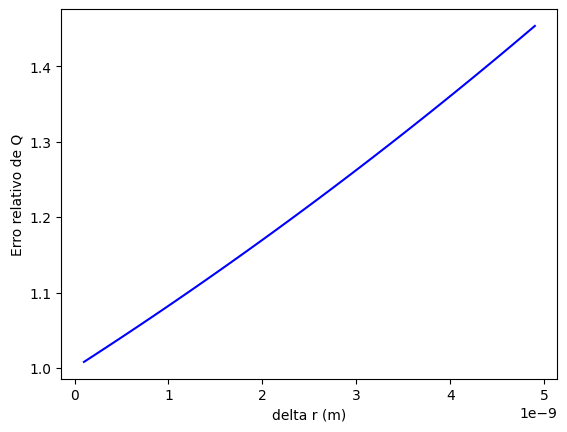

In [54]:
erd = []
for delta in deltar:
  erd.append(err_rel(calQd(rmais(rd, delta),pd, mid, Ld ),Qd))
plt.plot(deltar, erd, color = "blue")
plt.xlabel("delta r (m)")
plt.ylabel("Erro relativo de Q")
plt.show()

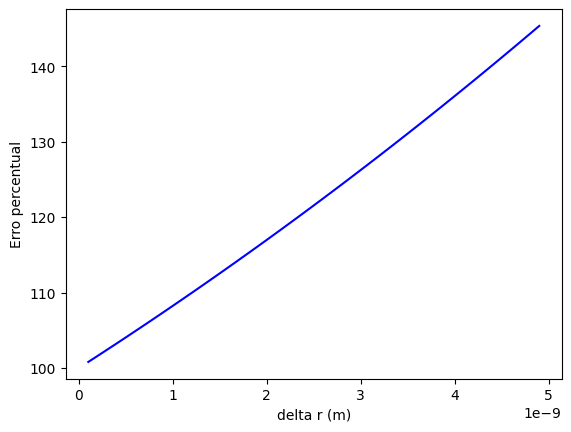

In [56]:
epd = []
for delta in deltar:
  epd.append(err_per(err_rel(calQd(rmais(rd, delta),pd, mid, Ld ),Qd)))
plt.plot(deltar, epd, color = "blue")
plt.xlabel("delta r (m)")
plt.ylabel ("Erro percentual")
plt.show()

In [62]:
def errorelativoexato(Q , Qmais):
  return (Qmais - Q) / Q

def errorelativoaproximado(r, deltarr):
  return 4*(deltarr / r)



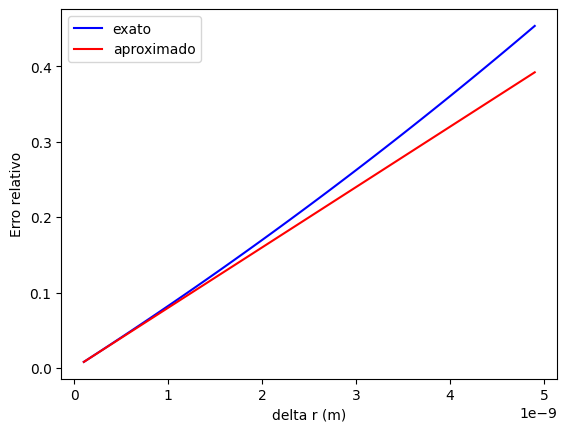

In [63]:
exad = []
eradd = []
for delta in deltar:
  exad.append(errorelativoexato(calQd(rd,pd,mid,Ld),calQd(rmais(rd,delta),pd,mid,Ld)))
  eradd.append(errorelativoaproximado(rd,delta))


plt.plot(deltar, exad, color = "blue", label = "exato")
plt.plot(deltar,eradd, color = "red", label = "aproximado")
plt.xlabel("delta r (m)")
plt.ylabel("Erro relativo")
plt.legend()
plt.show()


In [65]:
r32 = np.float32(rd)
rquarta32 = r32 ** 4
Q32 = calQd(r32,pd,mid,Ld)
print(f"r32 - {r32}")
print(f"r32 ** 4 - {rquarta32}")
print(f"Q32 - {Q32}")

print("\n")

r64 = np.float64(rd)
rquarta64 = r64 ** 4
Q64 = calQd(r64,pd,mid,Ld)
print(f"r64 - {r64}")
print(f"r64 ** 4 - {rquarta64}")
print(f"Q64 - {Q64}")


r32 - 5.000000058430487e-08
r32 ** 4 - 6.2500003959774226e-30
Q32 - 3.506242323744234e-19


r64 - 5e-08
r64 ** 4 - 6.249999999999999e-30
Q64 - 3.506241800881465e-19


In [66]:
diff_abs = abs(Q32 - Q64)
diff_rel = diff_abs / abs(Q64)

print(f"A diferença absoluta vale: {diff_abs}")
print(f"A diferença relativa vale: {diff_rel}")

A diferença absoluta vale: 5.228627689184328e-26
A diferença relativa vale: 1.4912342006389455e-07


In [67]:
print("eps float32:", np.finfo(np.float32).eps)
print("eps float64:", np.finfo(np.float64).eps)

eps float32: 1.1920929e-07
eps float64: 2.220446049250313e-16


In [69]:
def vaz1(Qmax, Q):
  return (Qmax - Q) / Q

def vaz2(deltar, r):
  return (1 + (deltar/r)) ** 4 - 1

In [79]:
deltarsobrer = [1e-1 , 1e-2 , 1e-3 , 1e-4 , 1e-5 , 1e-6 , 1e-7 , 1e-8 , 1e-9 , 1e-10,1e-11,1e-12,1e-13,1e-14,1e-15,1e-16,1e-17,1e-18]
vaso1 = []
vaso2 = []
for deltasobrer in deltarsobrer:
  dr = deltasobrer * rd

  Qvelho = calQd(rd,pd,mid,Ld)
  Qnovo = calQd( rd + dr ,pd,mid,Ld)
  vaso1.append(vaz1(Qnovo,Qvelho))

  vaso2.append(vaz2(dr,rd))
vaso1 = np.array(vaso1)
vaso2 = np.array(vaso2)
diferenca = []
for i in range(len(vaso1)):
  print(i)
  print(f"vaso1 - {vaso1[i]}")
  print(f"vaso2 - {vaso2[i]}")

0
vaso1 - 0.46409999999999957
vaso2 - 0.4641000000000004
1
vaso1 - 0.04060400999999966
vaso2 - 0.040604010000000024
2
vaso1 - 0.0040060040009997095
vaso2 - 0.004006004000999486
3
vaso1 - 0.00040006000399993394
vaso2 - 0.0004000600039999469
4
vaso1 - 4.000060000380733e-05
vaso2 - 4.0000600004308495e-05
5
vaso1 - 4.000006000021365e-06
vaso2 - 4.000005999760248e-06
6
vaso1 - 4.0000005972431173e-07
vaso2 - 4.000000601855902e-07
7
vaso1 - 4.000000060315938e-08
vaso2 - 4.0000000423034976e-08
8
vaso1 - 3.999999689547809e-09
vaso2 - 4.000000330961484e-09
9
vaso1 - 4.0000003761554553e-10
vaso2 - 4.000000330961484e-10
10
vaso1 - 3.9999838975719427e-11
vaso2 - 4.000000330961484e-11
11
vaso1 - 4.0000388261836515e-12
vaso2 - 4.000355602329364e-12
12
vaso1 - 4.0029225782983777e-13
vaso2 - 3.9968028886505635e-13
13
vaso1 - 4.023520807689278e-14
vaso2 - 3.9968028886505635e-14
14
vaso1 - 4.119645878180149e-15
vaso2 - 4.440892098500626e-15
15
vaso1 - 4.119645878180149e-16
vaso2 - 0.0
16
vaso1 - 0.0
vaso

A partir de 10^-12, os valores das vazões começam a se diferenciar mais, tendo diferença a partir da terceira casa significativa. Em 10^-15, a segunda fórmula de calcular vazão acaba zerando enquanto a primeira ainda tem valor e a partir de 10^-16, as duas fórmulas acabam zerando por causa de erro computacional

Isso ocorre, pois, quanto menor o raio, maior será a relação superfície/volume. Isso pode ser dito, pois a superfície está em r ^ 2, enquanto o volume em r^3, logo, quanto menor o raio, maior será a relação superfície/volume. Além disso, como o volume é r ^ 3 e a superfície r ^ 2, para r menor que 1, r ^ 2 > r ^ 3. Portanto, quanto menor o r, maior será a relevância dos efeitos viscosos e de parede (efeitos de superfície) em relação aos efeitos de volume.

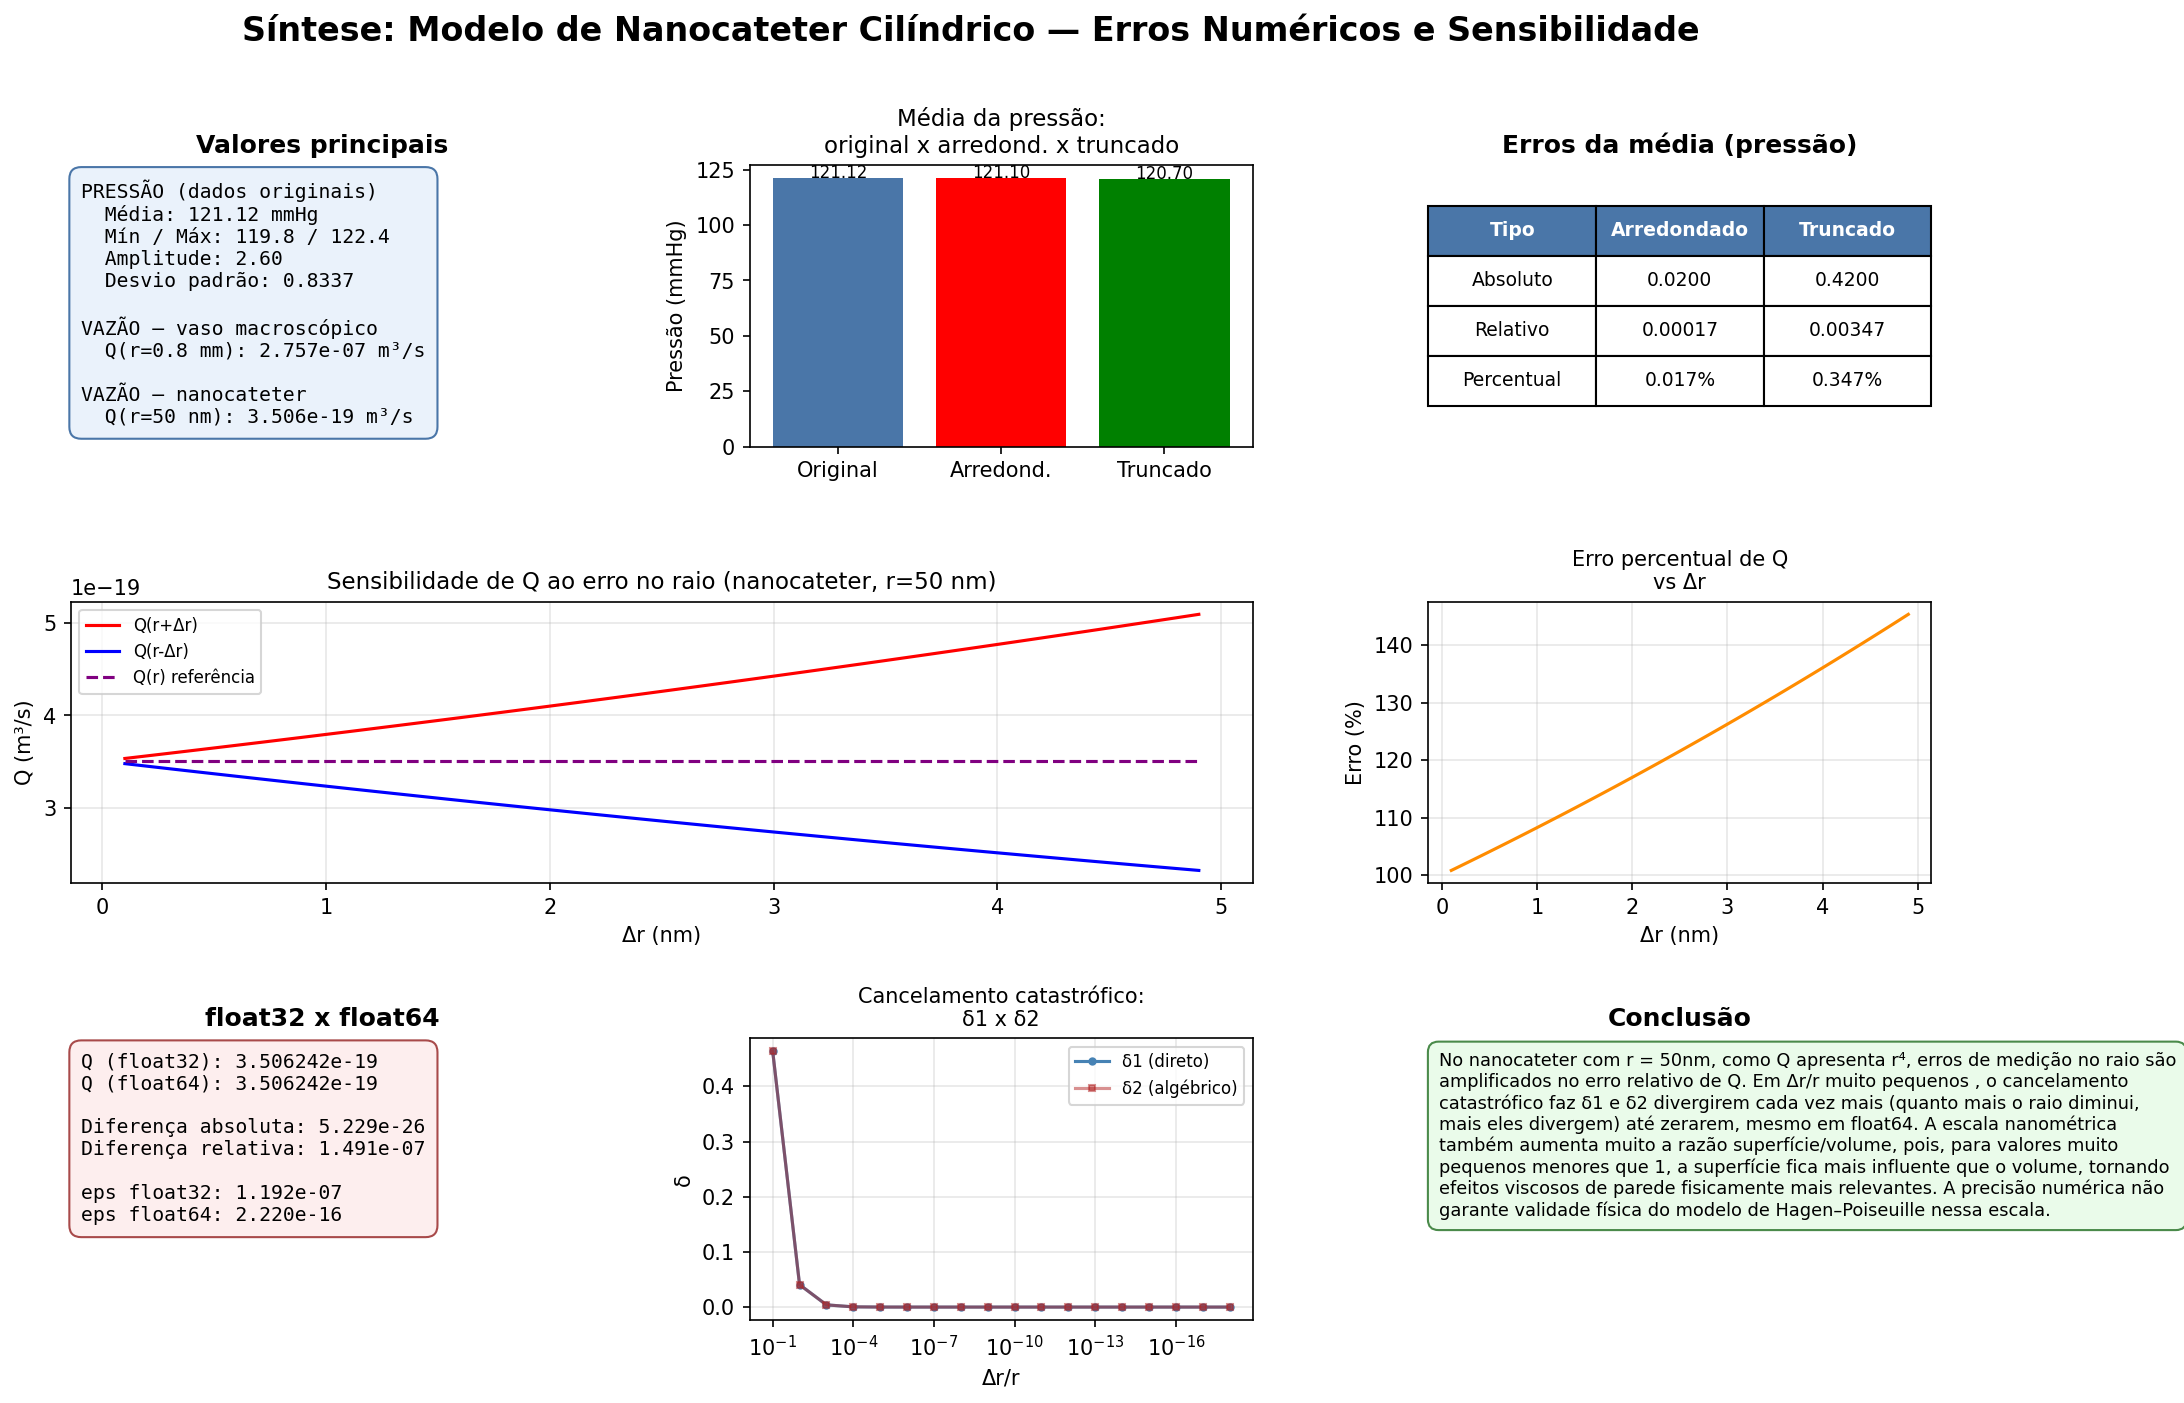

Tamanho aproximado: [2400. 1500.] pixels


In [85]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

# Garante tamanho mínimo de 1600x1000 px (aqui: 16 x 10 pol * 150 dpi = 2400x1500 px)
fig = plt.figure(figsize=(16, 10), dpi=150)
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.55, wspace=0.35)

fig.suptitle("Síntese: Modelo de Nanocateter Cilíndrico — Erros Numéricos e Sensibilidade",
             fontsize=16, fontweight='bold', y=0.98)

# ---------------------------------------------------------------
# PAINEL 1 — Cartões com valores principais de pressão e vazão
# ---------------------------------------------------------------
ax1 = fig.add_subplot(gs[0, 0])
ax1.axis('off')
ax1.set_title("Valores principais", fontsize=12, fontweight='bold')

cartoes_texto = (
    f"PRESSÃO (dados originais)\n"
    f"  Média: {medo:.2f} mmHg\n"
    f"  Mín / Máx: {mino:.1f} / {maxo:.1f}\n"
    f"  Amplitude: {ampo:.2f}\n"
    f"  Desvio padrão: {dpo:.4f}\n\n"
    f"VAZÃO — vaso macroscópico\n"
    f"  Q(r={ro} mm): {Qo:.3e} m³/s\n\n"
    f"VAZÃO — nanocateter\n"
    f"  Q(r=50 nm): {Qd:.3e} m³/s"
)
ax1.text(0.02, 0.95, cartoes_texto, transform=ax1.transAxes,
         fontsize=9.5, va='top', ha='left', family='monospace',
         bbox=dict(boxstyle="round,pad=0.6", facecolor="#eaf2fb", edgecolor="#4a76a8"))

# ---------------------------------------------------------------
# PAINEL 2 — Comparação truncamento x arredondamento (pressão)
# ---------------------------------------------------------------
ax2 = fig.add_subplot(gs[0, 1])
categorias = ["Original", "Arredond.", "Truncado"]
valores_media = [medo, medarre, medtrunc]
cores = ["#4a76a8", "red", "green"]
ax2.bar(categorias, valores_media, color=cores)
ax2.set_title("Média da pressão:\noriginal x arredond. x truncado", fontsize=11)
ax2.set_ylabel("Pressão (mmHg)")
for i, v in enumerate(valores_media):
    ax2.text(i, v + 0.05, f"{v:.2f}", ha='center', fontsize=8)

# ---------------------------------------------------------------
# PAINEL 3 — Os três tipos de erro (abs, rel, %) - arred x trunc
# ---------------------------------------------------------------
ax3 = fig.add_subplot(gs[0, 2])
ax3.axis('off')
ax3.set_title("Erros da média (pressão)", fontsize=12, fontweight='bold')

tabela_dados = [
    ["Tipo", "Arredondado", "Truncado"],
    ["Absoluto", f"{eaarr:.4f}", f"{eatrunc:.4f}"],
    ["Relativo", f"{erarr:.5f}", f"{ertrunc:.5f}"],
    ["Percentual", f"{eparr:.3f}%", f"{eptrunc:.3f}%"],
]
tab3 = ax3.table(cellText=tabela_dados, loc='center', cellLoc='center')
tab3.auto_set_font_size(False)
tab3.set_fontsize(9)
tab3.scale(1, 2)
tab3[(0,0)].set_facecolor("#4a76a8"); tab3[(0,0)].set_text_props(color='white', fontweight='bold')
tab3[(0,1)].set_facecolor("#4a76a8"); tab3[(0,1)].set_text_props(color='white', fontweight='bold')
tab3[(0,2)].set_facecolor("#4a76a8"); tab3[(0,2)].set_text_props(color='white', fontweight='bold')

# ---------------------------------------------------------------
# PAINEL 4 — Sensibilidade de Q ao raio (nanocateter)
# ---------------------------------------------------------------
ax4 = fig.add_subplot(gs[1, :2])
ax4.plot(deltar*1e9, Qmais, color="red", label="Q(r+Δr)")
ax4.plot(deltar*1e9, Qmenos, color="blue", label="Q(r-Δr)")
ax4.plot(deltar*1e9, Qnormal, color="purple", linestyle="--", label="Q(r) referência")
ax4.set_title("Sensibilidade de Q ao erro no raio (nanocateter, r=50 nm)", fontsize=11)
ax4.set_xlabel("Δr (nm)")
ax4.set_ylabel("Q (m³/s)")
ax4.legend(fontsize=8)
ax4.grid(alpha=0.3)

# Painel pequeno ao lado com erro percentual máximo
ax4b = fig.add_subplot(gs[1, 2])
ax4b.plot(deltar*1e9, epd, color="darkorange")
ax4b.set_title("Erro percentual de Q\nvs Δr", fontsize=10)
ax4b.set_xlabel("Δr (nm)")
ax4b.set_ylabel("Erro (%)")
ax4b.grid(alpha=0.3)

# ---------------------------------------------------------------
# PAINEL 5 — Comparação float32 x float64
# ---------------------------------------------------------------
ax5 = fig.add_subplot(gs[2, 0])
ax5.axis('off')
ax5.set_title("float32 x float64", fontsize=12, fontweight='bold')

eps32 = np.finfo(np.float32).eps
eps64 = np.finfo(np.float64).eps

texto5 = (
    f"Q (float32): {Q32:.6e}\n"
    f"Q (float64): {Q64:.6e}\n\n"
    f"Diferença absoluta: {diff_abs:.3e}\n"
    f"Diferença relativa: {diff_rel:.3e}\n\n"
    f"eps float32: {eps32:.3e}\n"
    f"eps float64: {eps64:.3e}"
)
ax5.text(0.02, 0.95, texto5, transform=ax5.transAxes,
         fontsize=9.5, va='top', ha='left', family='monospace',
         bbox=dict(boxstyle="round,pad=0.6", facecolor="#fdeeee", edgecolor="#a84a4a"))

# ---------------------------------------------------------------
# PAINEL 6 — δ1 vs δ2 (cancelamento catastrófico)
# ---------------------------------------------------------------
ax6 = fig.add_subplot(gs[2, 1])
ax6.semilogx(deltarsobrer, vaso1, marker='o', ms=3, label="δ1 (direto)", color="steelblue")
ax6.semilogx(deltarsobrer, vaso2, marker='s', ms=3,alpha = 0.5, label="δ2 (algébrico)", color="firebrick")
ax6.set_title("Cancelamento catastrófico:\nδ1 x δ2", fontsize=10)
ax6.set_xlabel("Δr/r")
ax6.set_ylabel("δ")
ax6.invert_xaxis()
ax6.legend(fontsize=8)
ax6.grid(alpha=0.3, which='both')

# ---------------------------------------------------------------
# PAINEL 7 — Conclusão
# ---------------------------------------------------------------
ax7 = fig.add_subplot(gs[2, 2])
ax7.axis('off')
ax7.set_title("Conclusão", fontsize=12, fontweight='bold')
conclusao = (
    "No nanocateter com r = 50nm, como Q apresenta r⁴, "
    "erros de medição no raio são amplificados "
    "no erro relativo de Q. Em Δr/r muito pequenos "
    ", o cancelamento catastrófico faz δ1 e "
    "δ2 divergirem cada vez mais (quanto mais o raio diminui, mais eles divergem) até zerarem, mesmo em float64. "
    "A escala nanométrica também aumenta muito a "
    "razão superfície/volume, pois, para valores muito pequenos menores que 1, a superfície fica mais influente que o volume, tornando efeitos "
    "viscosos de parede fisicamente mais relevantes. A "
    "precisão numérica não garante validade física "
    "do modelo de Hagen–Poiseuille nessa escala."
)
ax7.text(0.02, 0.95, conclusao, transform=ax7.transAxes,
         fontsize=8.5, va='top', ha='left', wrap=True,
         bbox=dict(boxstyle="round,pad=0.6", facecolor="#eafbea", edgecolor="#4a8a4a"))

plt.savefig("sintese_nanocateter.png", dpi=150, bbox_inches='tight')
plt.show()

print("Tamanho aproximado:", fig.get_size_inches() * fig.dpi, "pixels")

GIF salvo!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

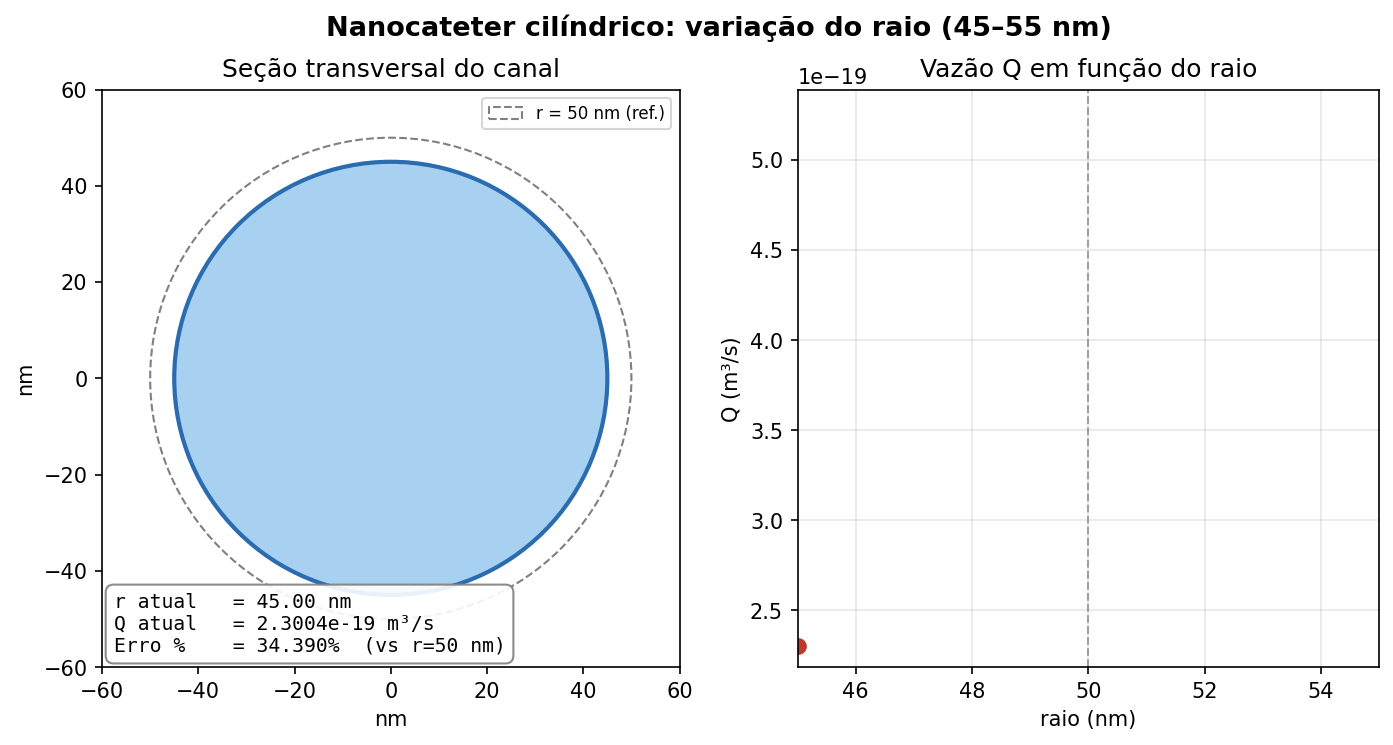

In [84]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import math

# ---------------------------------------------------------------
# Parâmetros do modelo (mesmos usados no notebook)
# ---------------------------------------------------------------
r_ref = 50e-9      # raio de referência (m)
L = 10e-6          # comprimento (m)
mi = 3.5e-3        # viscosidade (Pa.s)
dp = 5000          # diferença de pressão (Pa)

def calQ(r, p, mi, L):
    return math.pi * (r**4) * p / (8 * mi * L)

Q_ref = calQ(r_ref, dp, mi, L)

# ---------------------------------------------------------------
# Variação do raio: 45 a 55 nm, 50 quadros
# ---------------------------------------------------------------
n_frames = 50
raios_nm = np.linspace(45, 55, n_frames)
raios_m = raios_nm * 1e-9

Q_valores = [calQ(r, dp, mi, L) for r in raios_m]
erro_percentual = [abs(Q - Q_ref) / Q_ref * 100 for Q in Q_valores]

# ---------------------------------------------------------------
# Figura com 2 painéis: seção transversal (esquerda) e Q x r (direita)
# ---------------------------------------------------------------
fig, (ax_sec, ax_curva) = plt.subplots(1, 2, figsize=(11, 5), dpi=150)
fig.suptitle("Nanocateter cilíndrico: variação do raio (45–55 nm)",
             fontsize=13, fontweight='bold')

# --- Painel esquerdo: seção transversal ---
ax_sec.set_xlim(-60, 60)
ax_sec.set_ylim(-60, 60)
ax_sec.set_aspect('equal')
ax_sec.set_title("Seção transversal do canal")
ax_sec.set_xlabel("nm")
ax_sec.set_ylabel("nm")

circulo_ref = plt.Circle((0, 0), 50, fill=False, linestyle='--',
                          color='gray', linewidth=1, label='r = 50 nm (ref.)')
ax_sec.add_patch(circulo_ref)
circulo_atual = plt.Circle((0, 0), raios_nm[0], fill=True,
                            facecolor='#a8d0f0', edgecolor='#2b6cb0', linewidth=2)
ax_sec.add_patch(circulo_atual)
ax_sec.legend(loc='upper right', fontsize=8)

texto_info = ax_sec.text(0.02, 0.02,
                          "", transform=ax_sec.transAxes,
                          fontsize=9.5, va='bottom', ha='left', family='monospace',
                          bbox=dict(boxstyle="round,pad=0.4", facecolor="white",
                                    edgecolor="gray", alpha=0.9))

# --- Painel direito: curva Q x r sendo construída ---
ax_curva.set_xlim(45, 55)
ax_curva.set_ylim(min(Q_valores) * 0.95, max(Q_valores) * 1.05)
ax_curva.set_xlabel("raio (nm)")
ax_curva.set_ylabel("Q (m³/s)")
ax_curva.set_title("Vazão Q em função do raio")
ax_curva.grid(alpha=0.3)
ax_curva.axvline(50, color='gray', linestyle='--', linewidth=1, alpha=0.7)

linha_curva, = ax_curva.plot([], [], color='#c0392b', linewidth=2)
ponto_atual, = ax_curva.plot([], [], 'o', color='#c0392b', markersize=7)

# ---------------------------------------------------------------
# Função de atualização de cada quadro
# ---------------------------------------------------------------
def atualizar(frame):
    r_nm = raios_nm[frame]
    Q = Q_valores[frame]
    erro_pct = erro_percentual[frame]

    # Atualiza o círculo (seção transversal)
    circulo_atual.set_radius(r_nm)

    # Atualiza o texto informativo
    texto_info.set_text(
        f"r atual   = {r_nm:.2f} nm\n"
        f"Q atual   = {Q:.4e} m³/s\n"
        f"Erro %    = {erro_pct:.3f}%  (vs r=50 nm)"
    )

    # Atualiza a curva Q x r construída progressivamente
    linha_curva.set_data(raios_nm[:frame+1], Q_valores[:frame+1])
    ponto_atual.set_data([r_nm], [Q])

    return circulo_atual, texto_info, linha_curva, ponto_atual

# ---------------------------------------------------------------
# Cria a animação e salva como GIF
# ---------------------------------------------------------------
from google.colab import files

anim = animation.FuncAnimation(
    fig, atualizar, frames=n_frames, interval=150, blit=False
)

anim.save("nanocateter_variacao_raio.gif", writer='pillow', fps=7, dpi=150)
print("GIF salvo!")

files.download("nanocateter_variacao_raio.gif")